# Demonstration of SIVE model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import imageio.v2 as imageio
import torch

import glob
import os
os.chdir("src")

import evaluation as eval
import utils

### Load SIVE test set
Download here: https://zenodo.org/records/17122999

In [3]:
# Update paths as needed
seen_location_path = "../data/SIVE/test_1/"
unseen_location_path = "../data/SIVE/test_2/"
points_dict_path = "../data/SIVE/points_dict.npy"

points_dict = np.load(points_dict_path, allow_pickle=True).item()

In [4]:
# Load seen location test set
target_pos = -1

test_paths = glob.glob(seen_location_path + '*.npy')
test_targets = [np.load(file)[target_pos] for file in test_paths]
test_input = [np.load(file)[0:target_pos] for file in test_paths]

print("Test dimensions:")
print("Number of samples:", len(test_input))
print("Shape of target:", np.shape(test_targets[0]))
print("Shape of input:", np.shape(test_input[0]))

Test dimensions:
Number of samples: 9
Shape of target: (750, 650)
Shape of input: (5, 750, 650)


## Load model
Model is served using torch hub: https://github.com/conorosully/vegetation-line-models

<br>
Currently, only the best SimpleCNN and BigEarthNet models from the paper is provided.

In [5]:
# Load simpleCNN model trained on SIVE dataset
model, meta_data = torch.hub.load("conorosully/vegetation-line-models", 
                                    "simpleCNN_guided") #change to BigEarthNet for BigEarthNet model
print(meta_data)

Using cache found in /Users/conorosullivan/.cache/torch/hub/conorosully_vegetation-line-models_main


{'name': 'SIVE_SimpleCNN', 'date': '04/JUNE/2024', 'arcitecture': 'HED', 'backbone': 'SimpleCNN', 'freeze_backbone': False, 'guidance': True, 'loss_function': 'wBCE'}


In [6]:
# move model to GPU if available
device = torch.device('mps' if torch.backends.mps.is_built() 
                      else 'cuda' if torch.cuda.is_available() 
                      else 'cpu')
model.to(device)
print(f'Using device: {device}')

model

Using device: mps


HED(
  (backbone): SimpleCNNBackbone(
    (stage1): Sequential(
      (0): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (stage2): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (stage3): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
    )
    (stage4): Sequential(
      (0): MaxPool2d

## How `get_combined_pred` works

`get_combined_pred` splits a full test instance into overlapping 144x144 tiles centered on points along the vegetation line, runs the model on each tile, and stitches the tile-level predictions back together. The cells below unpack that process step by step, before it is called directly further down.

### 1. Select a single tile from a test instance

Number of tiles: 11


Text(0.5, 0.98, 'Tile 10 from 20190627T113321_bull_island')

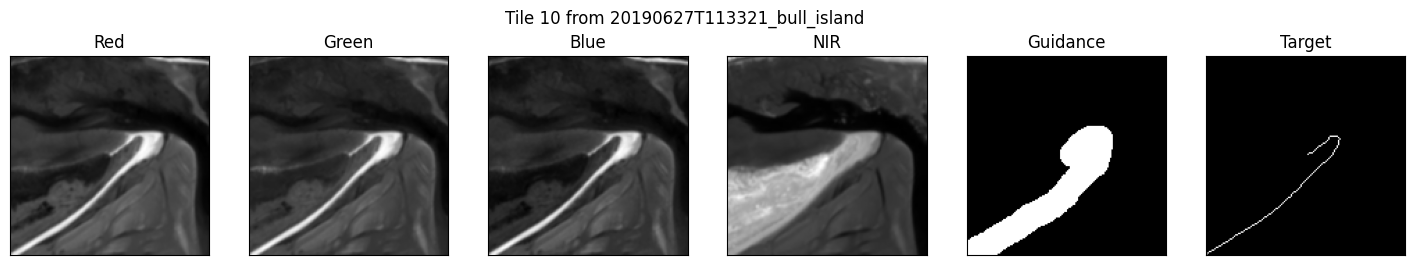

In [7]:
# Select a test instance
path = test_paths[7]
image = np.load(path)
ID = os.path.basename(path).split('.')[0]
points = points_dict[ID]

# Split the instance into the same overlapping tiles used by get_combined_pred
crop_paths, start_points = utils.get_iterative_crops(image, points)
print(f"Number of tiles: {len(crop_paths)}")

# Pick a single tile to inspect
tile_idx = 10
tile = np.load(crop_paths[tile_idx])

channel_names = ["Red", "Green", "Blue", "NIR", "Guidance", "Target"]

fig, ax = plt.subplots(1, 6, figsize=(18, 3))
for i, name in enumerate(channel_names):
    ax[i].imshow(tile[i], cmap='gray')
    ax[i].set_title(name)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
fig.suptitle(f"Tile {tile_idx} from {ID}")

### 2. Apply the model to this single tile

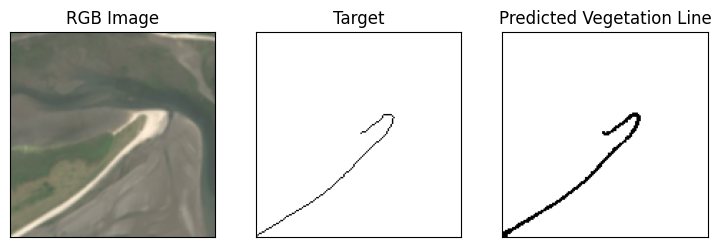

In [8]:
# Run the model on this single tile
target_crop, pred_crop = eval.get_preds(model, meta_data["guidance"], [crop_paths[tile_idx]],
                                         batch_size=1, device=device)

tile_rgb = utils.get_rgb(tile[0:4], r=0, g=1, b=2, contrast=0.4)

fig, ax = plt.subplots(1, 3, figsize=(9, 4))

ax[0].imshow(tile_rgb)
ax[0].set_title('RGB Image')

ax[1].imshow(1 - target_crop[0], cmap='gray')
ax[1].set_title('Target')

ax[2].imshow(1 - pred_crop[0], cmap='gray')
ax[2].set_title('Predicted Vegetation Line')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

### 3. Visualise `get_combined_pred` iterating along the coastline

This steps through every tile in the test instance in the same order used inside `get_combined_pred`. On the left is the full test instance with a dot for the centre of each tile and a square showing the current tile. On the right is the vegetation line detected so far - black for tiles already processed, grey for the tile just added.

In [9]:
# Run the model on every tile in the instance (same call get_combined_pred makes internally)
target_crops, pred_crops = eval.get_preds(model, meta_data["guidance"], crop_paths,
                                           batch_size=1, device=device)

crop_size = 144
H, W = image.shape[1], image.shape[2]
full_rgb = utils.get_rgb(image[0:4], r=0, g=1, b=2, contrast=0.4)

# Tile centres, in iteration order
centers = [(x + crop_size // 2, y + crop_size // 2) for x, y in start_points]
cx_all, cy_all = zip(*centers)

# Remove buffer for visualization (same crop used for the full test instance below)
buffer = 200
display_rgb = full_rgb[buffer:-buffer, buffer:-buffer]

frames = []
cumulative = np.zeros((H, W), dtype=np.float32)

for i in range(len(crop_paths)):
    x_start, y_start = start_points[i]

    # Line detected before this iteration vs. the new pixels this iteration adds
    previous = np.clip(cumulative, 0, 1).copy()
    cumulative[y_start:y_start + crop_size, x_start:x_start + crop_size] += pred_crops[i]
    current_only = np.clip(cumulative, 0, 1) - previous

    line_img = np.ones((H, W, 3), dtype=np.float32)
    line_img[previous > 0] = [0, 0, 0]
    line_img[current_only > 0] = [0.6, 0.6, 0.6]
    display_line = line_img[buffer:-buffer, buffer:-buffer]

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(display_rgb)
    ax[0].scatter([x - buffer for x in cx_all], [y - buffer for y in cy_all], c='magenta', s=15)
    ax[0].add_patch(Rectangle((x_start - buffer, y_start - buffer), crop_size, crop_size,
                               edgecolor='black', facecolor='none', linewidth=2))
    ax[0].set_title('Test instance')

    ax[1].imshow(display_line)
    ax[1].add_patch(Rectangle((x_start - buffer, y_start - buffer), crop_size, crop_size,
                               edgecolor='black', facecolor='none', linewidth=2))
    ax[1].set_title('Detected vegetation line')
    ax[1].legend(handles=[Patch(color='black', label='Previous'),
                           Patch(color=(0.6, 0.6, 0.6), label='Current')],
                 loc='upper left')

    for a in ax:
        a.set_xlim(0, display_rgb.shape[1])
        a.set_ylim(display_rgb.shape[0], 0)
        a.set_xticks([])
        a.set_yticks([])

    fig.canvas.draw()
    frame = np.array(fig.canvas.buffer_rgba())[:, :, :3]
    frames.append(frame)
    plt.close(fig)

gif_path = "../get_combined_pred_demo.gif"
imageio.mimsave(gif_path, frames, duration=800, loop=0)  # duration is in milliseconds per frame
print(f"Saved animation to {gif_path}")

Saved animation to ../get_combined_pred_demo.gif


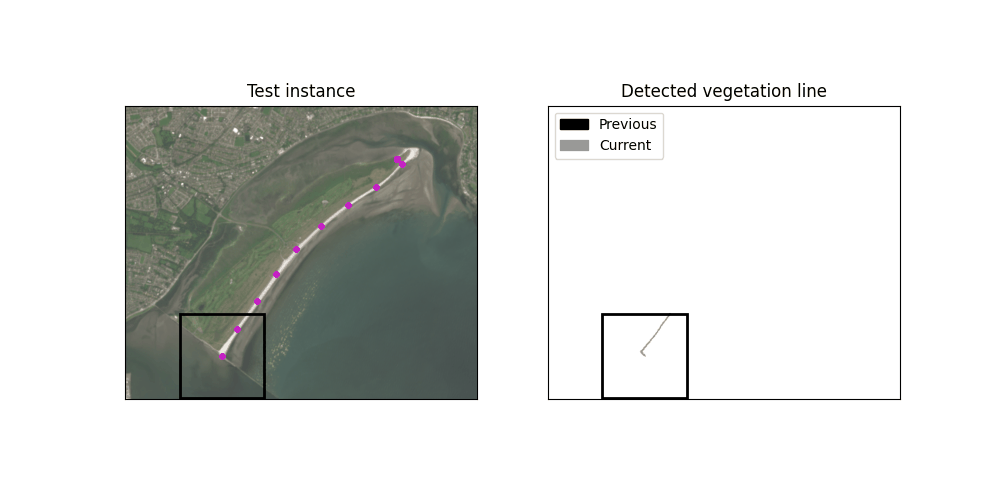

In [10]:
from IPython.display import Image as IPImage
IPImage(filename=gif_path)

### Apply model to multiple test instances
Includes examples from the seen test set as well as one instance from an unseen location (`unseen_location_path`).

In [11]:
# Indices into the seen test set to visualize
instances = [7,0,1,2]

# One example instance from the unseen location

unseen_test_paths = glob.glob(unseen_location_path + '*.npy')

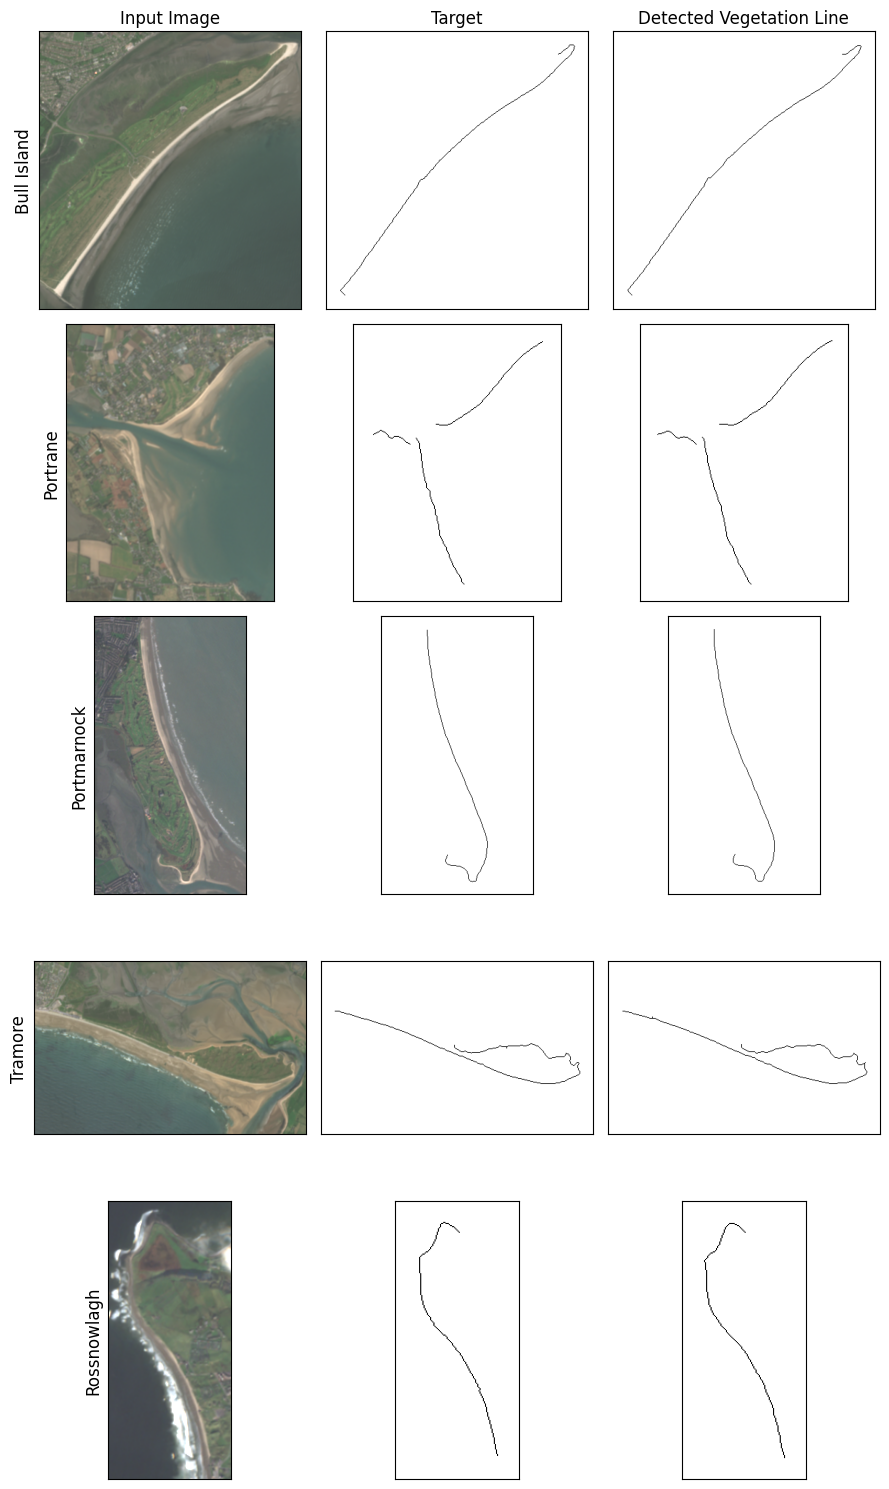

In [12]:
paths_to_show = [test_paths[i] for i in instances] + [unseen_test_paths[5]]
labels = ["Bull Island", "Portrane", "Portmarnock", "Tramore", "Rossnowlagh"]

fig, ax = plt.subplots(len(paths_to_show), 3, figsize=(9, 3 * len(paths_to_show)))

for row, (path, label) in enumerate(zip(paths_to_show, labels)):
    image, pred = eval.get_combined_pred(model, meta_data, points_dict, path, batch_size=1)
    target = image[-1]

    # Crop tightly around the detected vegetation line
    x1, x2, y1, y2 = utils.get_max_pos(pred, label)
    image = image[:, y1:y2, x1:x2]
    target = target[y1:y2, x1:x2]
    pred = pred[y1:y2, x1:x2]

    rgb_image = utils.get_rgb(image, r=0, g=1, b=2, contrast=0.4)

    ax[row, 0].imshow(rgb_image)
    ax[row, 1].imshow(1 - target, cmap='gray')
    ax[row, 2].imshow(1 - pred, cmap='gray')

    ax[row, 0].set_ylabel(label, fontsize=12)

    if row == 0:
        ax[row, 0].set_title('Input Image')
        ax[row, 1].set_title('Target')
        ax[row, 2].set_title('Detected Vegetation Line')

    for a in ax[row]:
        a.set_xticks([])
        a.set_yticks([])

plt.tight_layout()